In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import partial_r as pr
import importlib
importlib.reload(pr)
import matplotlib.pyplot as plt
from figure_formatting import setup_figure, save_figure
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
import logging
import matplotlib as mpl

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

In [3]:
PREFIXES = ['Association_', 'Cerebellum_', 'Commissure_', 'ProjectionBrainstem_', 'ProjectionBasalGanglia_']
STOPWORDS = {"of", "and", "in", "for", "to", "with", "on", "at"}

# regexes used repeatedly
RE_CAMEL_SPACE = re.compile(r'(?<!^)(?=[A-Z])') # capital letter that is not the first character in the string
RE_LR_END = re.compile(r'(L|R)$') # l/r at end of string
RE_MSMT_PREFIX = re.compile(r'^bundle_') # msmt prefix
RE_MM_SUFFIX = re.compile(r'\s*mm[23]?\s*$', flags=re.IGNORECASE) # trailing millimeter units e..g mm, mm2, mm3

def clean_metrics_name(name: str) -> str:
    name = str(name).replace('_', ' ')
    name = RE_MM_SUFFIX.sub('', name).strip() # remove mm units

    upper = name.upper()
    if upper.startswith("NODDI") or upper.startswith("DKI"):
        return " ".join(w.upper() for w in name.split())

    ordinal_allowed = "quarter" in name.lower()

    def ordinalize(token: str) -> str:
        n = int(token)
        if n % 10 == 1 and n % 100 != 11: return f"{n}st"
        if n % 10 == 2 and n % 100 != 12: return f"{n}nd"
        if n % 10 == 3 and n % 100 != 13: return f"{n}rd"
        return f"{n}th"

    cleaned = []
    for w in name.split():
        if w.isdigit():
            cleaned.append(ordinalize(w) if ordinal_allowed else w)
        elif w.lower() in STOPWORDS:
            cleaned.append(w.lower())
        else:
            cleaned.append(w.capitalize())
    return " ".join(cleaned)


In [4]:
# ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
ROOT_DIR = Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
INPUT_DIR = ROOT_DIR / "input_data"

abbrevs = pd.read_excel(INPUT_DIR / "abbreviations.xlsx", sheet_name="Sheet1")
annots = pd.read_csv(INPUT_DIR / "tract_sa_axis_ranges_thresh50.csv")

tracts = ['AssociationArcuateFasciculusL','AssociationArcuateFasciculusR', 'AssociationCingulumL', 'AssociationCingulumR',
          'AssociationExtremeCapsuleL', 'AssociationExtremeCapsuleR', 'AssociationFrontalAslantTractL','AssociationFrontalAslantTractR',
          'AssociationHippocampusAlveusL', 'AssociationHippocampusAlveusR', 'AssociationInferiorFrontoOccipitalFasciculusL',
          'AssociationInferiorFrontoOccipitalFasciculusR','AssociationInferiorLongitudinalFasciculusL',
          'AssociationInferiorLongitudinalFasciculusR','AssociationMiddleLongitudinalFasciculusL', 'AssociationMiddleLongitudinalFasciculusR',
          'AssociationParietalAslantTractL','AssociationParietalAslantTractR','AssociationSuperiorLongitudinalFasciculusL',
          'AssociationSuperiorLongitudinalFasciculusR', 'AssociationUncinateFasciculusL', 'AssociationUncinateFasciculusR',
          'AssociationVerticalOccipitalFasciculusL', 'AssociationVerticalOccipitalFasciculusR','CerebellumCerebellumL',
          'CerebellumCerebellumR','CerebellumInferiorCerebellarPeduncleL','CerebellumInferiorCerebellarPeduncleR',
          'CerebellumMiddleCerebellarPeduncle', 'CerebellumSuperiorCerebellarPeduncle','CerebellumVermis', 'CommissureCorpusCallosum',
          'ProjectionBasalGangliaAcousticRadiationL', 'ProjectionBasalGangliaAcousticRadiationR','ProjectionBasalGangliaAnsaLenticularisL',
          'ProjectionBasalGangliaAnsaLenticularisR', 'ProjectionBasalGangliaAnsaSubthalamicaL', 'ProjectionBasalGangliaAnsaSubthalamicaR',
          'ProjectionBasalGangliaCorticostriatalTractL', 'ProjectionBasalGangliaCorticostriatalTractR', 
          'ProjectionBasalGangliaFasciculusLenticularisL','ProjectionBasalGangliaFasciculusLenticularisR',
          'ProjectionBasalGangliaFasciculusSubthalamicusL', 'ProjectionBasalGangliaFasciculusSubthalamicusR', 'ProjectionBasalGangliaFornixL',
          'ProjectionBasalGangliaFornixR','ProjectionBasalGangliaOpticRadiationL', 'ProjectionBasalGangliaOpticRadiationR',
          'ProjectionBasalGangliaThalamicRadiationL', 'ProjectionBasalGangliaThalamicRadiationR', 'ProjectionBrainstemCorticopontineTractL',
          'ProjectionBrainstemCorticopontineTractR', 'ProjectionBrainstemCorticospinalTractL', 'ProjectionBrainstemCorticospinalTractR',
          'ProjectionBrainstemMedialForebrainBundleL', 'ProjectionBrainstemMedialForebrainBundleR', 'ProjectionBrainstemMedialLemniscusL',
          'ProjectionBrainstemMedialLemniscusR', 'ProjectionBrainstemNonDecussatingDentatorubrothalamicTractL',
          'ProjectionBrainstemNonDecussatingDentatorubrothalamicTractR', 'ProjectionBrainstemReticularTractL', 
          'ProjectionBrainstemReticularTractR']

prefixes = ["Association", "Cerebellum", "Commissure", "Projection"]

def add_prefix_underscore(tract):
    for p in prefixes:
        if tract.startswith(p):
            return tract.replace(p, p + "_", 1)
    return tract

tracts = [add_prefix_underscore(t) for t in tracts]

In [5]:
abbrevs.head(2)

,Tract,Abbreviation,HCPYA_1065,Hemisphere,Full_Name,Full_Name_capitalized,Tract_Long_Name,new_qsirecon_tract_names,Other_Nomenclatures,Type
0,AF_left,AF,AF_L,Left,arcuate fasciculus,Left Arcuate Fasciculus,Arcuate_Fasciculus_L,Association_ArcuateFasciculusL,NaN,Association
1,C_FPH_left,C_FPH,C_FPH_L,Left,"cingulum, frontal parahippocampal segment","Left Cingulum, Frontal Parahippocampal Segment",Cingulum_Frontal_Parahippocampal_L,NaN,NaN,Association


In [6]:
annots.head(2)

,Tract,SA_Range,N_Regions,Hemisphere,Abbreviation
0,FAT_left,168.0,26,left,FAT
1,AF_left,173.0,46,left,AF


In [7]:
abbrev_lookup = abbrevs[["new_qsirecon_tract_names", "Tract"]].drop_duplicates()
annot_lookup = annots[["Tract", "SA_Range"]].drop_duplicates()

abbrev_list = abbrev_lookup["new_qsirecon_tract_names"].dropna().tolist()
missing_tracts = [t for t in tracts if t not in abbrev_list]

print("Tracts not found in abbrevs['new_qsirecon_tract_names']:")
print(missing_tracts)
print(f"Total missing: {len(missing_tracts)}\n")

tracts_df = pd.DataFrame({"new_qsirecon_tract_names": tracts})

tracts_with_sa = (
    tracts_df
    .merge(abbrev_lookup, on="new_qsirecon_tract_names", how="left")
    .merge(annot_lookup, on="Tract", how="left")
)

tracts_with_sa_clean = tracts_with_sa.dropna()

for _, row in tracts_with_sa_clean.iterrows():
    print(row.to_dict())

Tracts not found in abbrevs['new_qsirecon_tract_names']:
['Association_ExtremeCapsuleL', 'Association_ExtremeCapsuleR', 'Association_HippocampusAlveusL', 'Association_HippocampusAlveusR', 'Cerebellum_CerebellumL', 'Cerebellum_CerebellumR', 'Cerebellum_InferiorCerebellarPeduncleL', 'Cerebellum_InferiorCerebellarPeduncleR', 'Cerebellum_MiddleCerebellarPeduncle', 'Cerebellum_SuperiorCerebellarPeduncle', 'Cerebellum_Vermis', 'Commissure_CorpusCallosum', 'Projection_BasalGangliaAcousticRadiationL', 'Projection_BasalGangliaAcousticRadiationR', 'Projection_BasalGangliaAnsaLenticularisL', 'Projection_BasalGangliaAnsaLenticularisR', 'Projection_BasalGangliaAnsaSubthalamicaL', 'Projection_BasalGangliaAnsaSubthalamicaR', 'Projection_BasalGangliaCorticostriatalTractL', 'Projection_BasalGangliaCorticostriatalTractR', 'Projection_BasalGangliaFasciculusLenticularisL', 'Projection_BasalGangliaFasciculusLenticularisR', 'Projection_BasalGangliaFasciculusSubthalamicusL', 'Projection_BasalGangliaFasciculu

In [8]:
tracts_with_sa_clean

,new_qsirecon_tract_names,Tract,SA_Range
0,Association_ArcuateFasciculusL,AF_left,173.0
1,Association_ArcuateFasciculusR,AF_right,140.0
2,Association_CingulumL,C_FP_left,116.0
3,Association_CingulumR,C_FP_right,159.0
6,Association_FrontalAslantTractL,FAT_left,168.0
7,Association_FrontalAslantTractR,FAT_right,156.0
10,Association_InferiorFrontoOccipitalFasciculusL,IFOF_left,171.0
11,Association_InferiorFrontoOccipitalFasciculusR,IFOF_right,171.0
12,Association_InferiorLongitudinalFasciculusL,ILF_left,167.0
13,Association_InferiorLongitudinalFasciculusR,ILF_right,178.0


In [9]:
FIG3_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure3"
SUPPFIG4_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig4"
for d in [FIG3_DIR, SUPPFIG4_DIR]:
    d.mkdir(parents=True, exist_ok=True)

scenarios = [("NODDI", False), ("DKI", False)]
split_modes = ["avg", "A", "B"]

for scenario_name, scenario_etiv in scenarios:
    print(f"\n[SCENARIO] {scenario_name} | eTIV={scenario_etiv}")

    for split_mode in split_modes:
        print(f"  [SPLIT_MODE] {split_mode}")

        if scenario_name == "NODDI" and scenario_etiv is False:
            save_dir = FIG3_DIR
            out_base = f"pca_ALL_LRkept_{split_mode}"
            file_stub = f"PC1_loading_and_scatter_{split_mode}"
        elif scenario_name == "DKI" and scenario_etiv is False:
            save_dir = SUPPFIG4_DIR
            out_base = f"pca_ALL_LRkept_dki_{split_mode}"
            file_stub = f"PC1_loading_and_scatter_dki_{split_mode}"
        else:
            continue

        pc_scores_df = pd.read_csv(save_dir / f"{out_base}_bundle_scores_PC12.csv")
        pc_loadings_df = pd.read_csv(save_dir / f"{out_base}_metric_loadings_PC12.csv")

        pc1_loadings = pc_loadings_df.set_index("metric")["PC1"].dropna().sort_values(ascending=True)
        pc1_loadings.index = [clean_metrics_name(m) for m in pc1_loadings.index]

        if pc1_loadings.index.duplicated().any():
            counts = {}
            new_idx = []
            for lbl in pc1_loadings.index:
                counts[lbl] = counts.get(lbl, 0) + 1
                new_idx.append(lbl if counts[lbl] == 1 else f"{lbl} ({counts[lbl]})")
            pc1_loadings.index = new_idx

        df_merged = pc_scores_df.merge(
            tracts_with_sa_clean[["new_qsirecon_tract_names", "SA_Range"]],
            left_on="bundle",
            right_on="new_qsirecon_tract_names",
            how="inner"
        )
        data_scatter = df_merged[["SA_Range", "PC1"]].dropna()

        x = data_scatter["SA_Range"].values
        y = data_scatter["PC1"].values
        r, _ = pearsonr(x, y)

        # Do not permute bundles for inference: bundles are not exchangeable and
        # their effects are correlated. The participant-level bootstrap section
        # below provides the inferential CI/p-value after refitting the full
        # mass-univariate -> PCA pipeline. This figure reports descriptive r only.

        if scenario_name == "DKI":
            height_mm = 90 
        else:
            height_mm = 75

        sns.set_style("white")
        fig, axes = setup_figure(
            width_mm=150,
            height_mm=height_mm,
            margins_mm=(42, 10, 10, 2),
            axes_linewidth=0.8,
            nrows=1,
            ncols=2,
            sharex=False,
            sharey=False
        )
        ax0, ax1 = axes.ravel()
        fig.subplots_adjust(wspace=0.35)

        ax0.barh(pc1_loadings.index, pc1_loadings.values, color="#7BA6E6")
        ax0.axvline(0, color="black", lw=1)
        ax0.set_xlabel("PC1 Loadings")
        ax0.set_ylabel("")
        sns.despine(ax=ax0, top=True, right=True)

        sns.regplot(
            data=data_scatter,
            x="SA_Range",
            y="PC1",
            scatter=False,
            ci=95,
            line_kws={"color": "black", "lw": 2},
            ax=ax1
        )
        sc = ax1.scatter(
            data_scatter["SA_Range"],
            data_scatter["PC1"],
            c=data_scatter["PC1"],
            cmap="viridis",
            s=45,
            alpha=0.85,
            edgecolor="none"
        )

        ax1.set_xlabel("SA Range")
        ax1.set_ylabel("PC1 Score")
        sns.despine(ax=ax1, top=True, right=True)

        ax1.text(
            0.05, 0.92,
            rf"$\it{{r}}$ = {r:.2f}",
            transform=ax1.transAxes,
            fontsize=7,
            ha="left",
            va="top"
        )

        ax0.tick_params(axis="both", which="both", bottom=True, left=True)
        ax1.tick_params(axis="both", which="both", bottom=True, left=True)

        cax = inset_axes(
            ax1, width="3%", height="30%", loc="upper left",
            bbox_to_anchor=(1.02, 0, 1, 1),
            bbox_transform=ax1.transAxes,
            borderpad=0
        )
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("PC1 score")
        cbar.set_ticks([-6, 0, 6])
        cbar.set_ticklabels(["-6", "0", "6"])
        cbar.ax.tick_params(which="both", length=0)

        svg_path = save_dir / f"{file_stub}.svg"
        png_path = save_dir / f"{file_stub}.png"
        save_figure(fig, svg_path, autofit=False)
        fig.savefig(png_path, dpi=600, bbox_inches="tight")

        print(f"[SAVE] → {svg_path}")
        print(f"[SAVE] → {png_path}")
        plt.close(fig)


[SCENARIO] NODDI | eTIV=False
  [SPLIT_MODE] avg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/PC1_loading_and_scatter_avg.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/PC1_loading_and_scatter_avg.png
  [SPLIT_MODE] A
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/PC1_loading_and_scatter_A.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/PC1_loading_and_scatter_A.png
  [SPLIT_MODE] B
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/PC1_loading_and_scatter_B.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/PC1_loading_and_scatter_B.png

[SCEN

In [10]:
from scipy.stats import pearsonr

scenarios = [("NODDI", False), ("DKI", False)]

for scenario_name, scenario_etiv in scenarios:
    print(f"\n[SCENARIO] {scenario_name} | eTIV={scenario_etiv}")

    if scenario_name == "NODDI" and scenario_etiv is False:
        save_dir = FIG3_DIR
        out_base_A = "pca_ALL_LRkept_A"
        out_base_B = "pca_ALL_LRkept_B"
        out_stub = "loading_corr_splitA_vs_splitB"
    elif scenario_name == "DKI" and scenario_etiv is False:
        save_dir = SUPPFIG4_DIR
        out_base_A = "pca_ALL_LRkept_dki_A"
        out_base_B = "pca_ALL_LRkept_dki_B"
        out_stub = "loading_corr_splitA_vs_splitB_dki"
    else:
        continue

    # read saved loading tables
    loadings_A = pd.read_csv(save_dir / f"{out_base_A}_metric_loadings_PC12.csv")
    loadings_B = pd.read_csv(save_dir / f"{out_base_B}_metric_loadings_PC12.csv")

    # merge on metric
    merged = loadings_A.merge(
        loadings_B,
        on="metric",
        suffixes=("_A", "_B"),
        how="inner"
    )

    results = []

    for pc in ["PC1", "PC2"]:
        x = merged[f"{pc}_A"].values
        y = merged[f"{pc}_B"].values

        # sign-align split B to split A so PCA sign flips do not look unstable
        r_raw, _ = pearsonr(x, y)
        if r_raw < 0:
            merged[f"{pc}_B"] = -merged[f"{pc}_B"]
            y = merged[f"{pc}_B"].values

        r, p = pearsonr(x, y)

        results.append({
            "PC": pc,
            "r": r,
            "p": p,
            "n_metrics": len(x)
        })

        print(f"{pc}: r = {r:.3f}, p = {p:.4g}, n = {len(x)}")

    results_df = pd.DataFrame(results)
    results_path = save_dir / f"{out_stub}_PC12.csv"
    results_df.to_csv(results_path, index=False)

    print(f"[SAVE] → {results_path}")


[SCENARIO] NODDI | eTIV=False
PC1: r = 0.963, p = 3.208e-12, n = 21
PC2: r = 0.986, p = 3.602e-16, n = 21
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3/loading_corr_splitA_vs_splitB_PC12.csv

[SCENARIO] DKI | eTIV=False
PC1: r = 0.989, p = 4.046e-22, n = 27
PC2: r = 0.979, p = 8.022e-19, n = 27
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig4/loading_corr_splitA_vs_splitB_dki_PC12.csv


### participant bootstrap and tract length

The bootstrap resamples **participants before the mass-univariate analysis**. Split A and split B participants are resampled separately with replacement, and every resampled participant carries their entire multitract/multimetric imaging vector with them. Each replicate then reruns the same General Exposome partial-r estimand used by `partial_r.run_partial_r`, averages the split-half effect matrices, refits PCA, aligns the arbitrary sign of PC1, and recomputes the PC1–S–A association with and without tract length adjustment.

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

REVIEW_DIR = ROOT_DIR / "output_data" / "results" / "reviewer_revision" / "sa_axis_bootstrap"
REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# N_BOOT = 2000
N_BOOT = 2
BOOT_SEED = 20260813
PROGRESS_EVERY = 50

TARGET = "General_SES"
CONTROL_COVARS = [
    "age", "sex", "t1post_dwi_contrast",
    "School", "Family_Values", "Family_Turmoil",
    "Dense_Urban_Poverty", "Extracurriculars", "Screen_Time",]

RESULTS_DIR = ROOT_DIR / "output_data" / "results"

# Primary NODDI + macrostructural data used for Figure 2 / Figure 3.
dfA_raw = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_12_10.csv")
dfB_raw = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_12_10.csv")

dfA_raw = dfA_raw[dfA_raw["matched_group"] == 1].copy().reset_index(drop=True)
dfB_raw = dfB_raw[dfB_raw["matched_group"] == 2].copy().reset_index(drop=True)

print("Split A:", dfA_raw.shape)
print("Split B:", dfB_raw.shape)

Split A: (4078, 1508)
Split B: (4096, 1508)


In [13]:

def clean_bundle_columns_corrected(df):
    df = df.copy()

    bundle_cols_mean = [
        c for c in df.columns
        if c.startswith("bundle_") and c.endswith("_mean")
    ]
    df = df.drop(columns=bundle_cols_mean, errors="ignore")

    df = df.rename(columns=lambda c: c[:-len("_median")]
                   if c.startswith("bundle_") and c.endswith("_median")
                   else c)
    return df


def parse_feature_name(feature):
    """Return bundle and metric names from bundle_<class>_<tract>_<metric>."""
    parts = str(feature).split("_")
    if len(parts) < 4 or parts[0] != "bundle":
        raise ValueError(f"Unexpected bundle feature name: {feature}")
    bundle = parts[1] + "_" + parts[2]
    metric = "_".join(parts[3:]).lower()
    return bundle, metric


dfA_boot = clean_bundle_columns_corrected(dfA_raw)
dfB_boot = clean_bundle_columns_corrected(dfB_raw)

msmt_cols_A = sorted(c for c in dfA_boot.columns if c.startswith("bundle_"))
msmt_cols_B = sorted(c for c in dfB_boot.columns if c.startswith("bundle_"))
msmt_cols = sorted(set(msmt_cols_A).intersection(msmt_cols_B))

if len(msmt_cols) != len(msmt_cols_A) or len(msmt_cols) != len(msmt_cols_B):
    print("WARNING: split A/B bundle-feature columns are not identical; using their intersection.")

feature_info = pd.DataFrame(
    [(c, *parse_feature_name(c)) for c in msmt_cols],
    columns=["feature", "bundle", "metric"]
)

bundles_boot = sorted(feature_info["bundle"].unique())
metrics_boot = sorted(feature_info["metric"].unique())

print(f"Bootstrap mass-univariate features: {len(msmt_cols)}")
print(f"Bundles: {len(bundles_boot)}")
print(f"Metrics entering PCA: {len(metrics_boot)}")
print("Metrics used in corrected PC1:")
print(metrics_boot)

if "mean_length_mm" not in metrics_boot:
    raise RuntimeError(
        "mean_length_mm is missing from the corrected bootstrap feature set. "
        "Do not continue until the raw column naming is inspected."
    )
print("[CHECK] mean_length_mm is included in the corrected PCA feature set.")


Bootstrap mass-univariate features: 1302
Bundles: 62
Metrics entering PCA: 21
Metrics used in corrected PC1:
['1st_quarter_volume_mm3', '2nd_and_3rd_quarter_volume_mm3', '4th_quarter_volume_mm3', 'area_of_end_region_1_mm2', 'area_of_end_region_2_mm2', 'curl', 'elongation', 'irregularity', 'mean_length_mm', 'noddi_icvf', 'noddi_isovf', 'noddi_od', 'radius_of_end_region_1_mm', 'radius_of_end_region_2_mm', 'span_mm', 'total_area_of_end_regions_mm2', 'total_radius_of_end_regions_mm', 'total_surface_area_mm2', 'total_volume_mm3', 'volume_of_end_branches_1', 'volume_of_end_branches_2']
[CHECK] mean_length_mm is included in the corrected PCA feature set.


In [14]:
# -----------------------------------------------------------------------------
# Fast, exact-equivalent implementation of pr.run_partial_r for bootstrap use.
#
# pr.run_partial_r does, for every imaging feature:
#   1) z-score y and all predictors;
#   2) fit a full OLS model containing General_SES + nuisance covariates;
#   3) fit a reduced OLS model without General_SES;
#   4) partial R2 = (R2_full - R2_reduced) / (1 - R2_reduced);
#   5) signed partial r = sign(beta_General_SES) * sqrt(abs(partial R2)).
# -----------------------------------------------------------------------------
COVARIATES = [
    "age", "sex", "t1post_dwi_contrast",
    "General_SES", "School", "Family_Values", "Family_Turmoil",
    "Dense_Urban_Poverty", "Extracurriculars", "Screen_Time",]


def prepare_split_arrays_exact(df, msmt_cols, covariates=COVARIATES, target=TARGET):
    required = list(covariates) + list(msmt_cols)
    missing_cols = [c for c in required if c not in df.columns]
    if missing_cols:
        raise RuntimeError(f"Required columns missing: {missing_cols[:20]}")

    # Match pr.run_partial_r: predictors are used directly as numeric columns.
    # Do not dummy-code or otherwise transform categorical variables here.
    try:
        P = df[covariates].to_numpy(dtype=float)
        Y = df[msmt_cols].to_numpy(dtype=float)
    except Exception as exc:
        raise RuntimeError(
            "The bootstrap predictors/features are not all numeric. "
            "pr.run_partial_r also requires numeric input, so inspect the source data."
        ) from exc

    if not np.isfinite(P).all():
        bad = int((~np.isfinite(P)).sum())
        raise RuntimeError(
            f"Found {bad} non-finite predictor values. The bootstrap will not silently "
            "change the analysis sample; resolve this before continuing."
        )
    if not np.isfinite(Y).all():
        bad = int((~np.isfinite(Y)).sum())
        raise RuntimeError(
            f"Found {bad} non-finite imaging values. The bootstrap will not silently "
            "use a different complete-case sample than pr.run_partial_r."
        )

    if target not in covariates:
        raise RuntimeError(f"Target {target!r} is not in the covariate list.")

    return {
        "P": P,
        "Y": Y,
        "predictor_names": list(covariates),
        "feature_names": list(msmt_cols),
        "target_index": list(covariates).index(target),
        "df": df,
    }


def partial_r_fast_exact(prep, indices=None):
    """Vectorized reproduction of pr.run_partial_r partial_r values.

    This intentionally reproduces the full/reduced R2 definition rather than
    using a different regression estimand. FDR/p-values from the mass-univariate
    models are not needed for the downstream PCA, so only partial_r is returned.
    """
    if indices is None:
        P = prep["P"]
        Y = prep["Y"]
    else:
        P = prep["P"][indices]
        Y = prep["Y"][indices]

    # Same scaling convention as sklearn StandardScaler in pr.run_partial_r.
    Pz = StandardScaler().fit_transform(P)
    Yz = StandardScaler().fit_transform(Y)

    target_idx = prep["target_index"]
    reduced_idx = [j for j in range(Pz.shape[1]) if j != target_idx]

    X_full = np.column_stack([np.ones(len(Pz)), Pz])
    X_red = np.column_stack([np.ones(len(Pz)), Pz[:, reduced_idx]])

    # statsmodels OLS.fit() defaults to a pseudoinverse solution; use pinv here
    # as well to behave consistently even if a bootstrap sample is rank deficient.
    beta_full = np.linalg.pinv(X_full) @ Yz
    beta_red = np.linalg.pinv(X_red) @ Yz

    resid_full = Yz - X_full @ beta_full
    resid_red = Yz - X_red @ beta_red

    sse_full = np.sum(resid_full ** 2, axis=0)
    sse_red = np.sum(resid_red ** 2, axis=0)
    y_centered = Yz - np.mean(Yz, axis=0, keepdims=True)
    tss = np.sum(y_centered ** 2, axis=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        r2_full = 1.0 - sse_full / tss
        r2_red = 1.0 - sse_red / tss
        partial_r2 = (r2_full - r2_red) / (1.0 - r2_red)

    # +1 because beta_full row 0 is the intercept.
    sign = np.sign(beta_full[target_idx + 1, :])
    partial_r = sign * np.sqrt(np.abs(partial_r2))
    return partial_r


prepA = prepare_split_arrays_exact(dfA_boot, msmt_cols)
prepB = prepare_split_arrays_exact(dfB_boot, msmt_cols)

print("Bootstrap N, split A:", len(prepA["Y"]))
print("Bootstrap N, split B:", len(prepB["Y"]))
print("Predictors (exactly as passed to pr.run_partial_r):", prepA["predictor_names"])


Bootstrap N, split A: 4078
Bootstrap N, split B: 4096
Predictors (exactly as passed to pr.run_partial_r): ['age', 'sex', 't1post_dwi_contrast', 'General_SES', 'School', 'Family_Values', 'Family_Turmoil', 'Dense_Urban_Poverty', 'Extracurriculars', 'Screen_Time']


In [15]:
# -----------------------------------------------------------------------------
# Convert partial-r vectors to bundle × metric matrices and recompute PCA.
# -----------------------------------------------------------------------------
bundle_to_i = {b: i for i, b in enumerate(bundles_boot)}
metric_to_j = {m: j for j, m in enumerate(metrics_boot)}
feature_positions = [
    (bundle_to_i[b], metric_to_j[m])
    for b, m in feature_info[["bundle", "metric"]].itertuples(index=False, name=None)]

def r_vector_to_matrix(r_values):
    mat = np.full((len(bundles_boot), len(metrics_boot)), np.nan, dtype=float)
    for value, (i, j) in zip(r_values, feature_positions):
        mat[i, j] = value
    if np.isnan(mat).any():
        missing = int(np.isnan(mat).sum())
        raise ValueError(f"Bundle × metric matrix contains {missing} missing cells.")
    return mat

def pca_from_split_r(rA, rB):
    matA = r_vector_to_matrix(rA)
    matB = r_vector_to_matrix(rB)
    mat_avg = (matA + matB) / 2.0

    Xz = StandardScaler().fit_transform(mat_avg)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(Xz)

    return {
        "scores": scores,
        "loadings": pca.components_.T,
        "explained": pca.explained_variance_ratio_.copy(),
        "matrix": mat_avg}

# Reference PC1 saved by Figure 2 notebook.
ref_scores_df = pd.read_csv(FIG3_DIR / "pca_ALL_LRkept_avg_bundle_scores_PC12.csv")
ref_loadings_df = pd.read_csv(FIG3_DIR / "pca_ALL_LRkept_avg_metric_loadings_PC12.csv")
ref_loading_map = ref_loadings_df.set_index("metric")["PC1"].to_dict()

def align_pc1_to_reference(pca_result):
    current = np.asarray(pca_result["loadings"][:, 0], dtype=float)
    ref = np.array([ref_loading_map.get(m, np.nan) for m in metrics_boot], dtype=float)
    valid = np.isfinite(current) & np.isfinite(ref)

    if valid.sum() < 3: raise ValueError("Too few overlapping metric loadings to align bootstrap PC1.")

    loading_r = pearsonr(current[valid], ref[valid])[0]
    sign = -1.0 if loading_r < 0 else 1.0

    pc1 = pca_result["scores"][:, 0] * sign
    pc1_loadings = current * sign
    return pc1, pc1_loadings, abs(loading_r)

# -----------------------------------------------------------------------------
# VALIDATION 1: compare against the corrected Figure 2 effects, which were generated with pr.run_partial_r.
# -----------------------------------------------------------------------------
rA_observed = partial_r_fast_exact(prepA)
rB_observed = partial_r_fast_exact(prepB)

saved_partial_path = (RESULTS_DIR / "supplemental_figures" / "suppfig9" / "partial_r_General_SES_NODDI_etivFalse.csv")
saved_exact = pd.read_csv(saved_partial_path)

if "group" not in saved_exact.columns:
    raise RuntimeError(f"Expected a 'group' column in {saved_partial_path}. Rerun corrected Figure 2 first.")

def validate_against_saved(fast_values, group):
    exact = (
        saved_exact.loc[saved_exact["group"] == group, ["feature", "partial_r"]]
        .drop_duplicates("feature")
        .set_index("feature")
    )
    missing = [f for f in msmt_cols if f not in exact.index]
    if missing:
        raise RuntimeError(
            f"Corrected Figure 2 output is missing {len(missing)} bootstrap features "
            f"(e.g. {missing[:5]}). Rerun corrected Figure 2 so mean_length_mm is included."
        )
    exact_values = exact.loc[msmt_cols, "partial_r"].to_numpy(dtype=float)
    diff = np.abs(fast_values - exact_values)
    return float(np.nanmax(diff)), float(pearsonr(fast_values, exact_values)[0])

maxdiff_A, corr_A = validate_against_saved(rA_observed, "A")
maxdiff_B, corr_B = validate_against_saved(rB_observed, "B")
print(f"Observed fast-vs-pr.run_partial_r split A: max |Δr|={maxdiff_A:.3e}, r={corr_A:.12f}")
print(f"Observed fast-vs-pr.run_partial_r split B: max |Δr|={maxdiff_B:.3e}, r={corr_B:.12f}")

EXACT_TOL = 1e-8
if max(maxdiff_A, maxdiff_B) > EXACT_TOL:
    raise RuntimeError(
        "Fast bootstrap backend does not numerically reproduce pr.run_partial_r "
        f"within tolerance {EXACT_TOL}. Stop before bootstrapping.")

# -----------------------------------------------------------------------------
# VALIDATION 2: literally call pr.run_partial_r on participant bootstrap draws
# for a feature subset. This confirms equivalence after duplicated participant
# rows / resampling, not only in the observed sample.
# -----------------------------------------------------------------------------
VALIDATION_BOOT_DRAWS = 2
VALIDATION_N_FEATURES = min(30, len(msmt_cols))
VALIDATION_SEED = BOOT_SEED + 11
rng_validate = np.random.default_rng(VALIDATION_SEED)
feature_idx_validate = np.sort(
    rng_validate.choice(len(msmt_cols), size=VALIDATION_N_FEATURES, replace=False)
)
features_validate = [msmt_cols[i] for i in feature_idx_validate]

validation_diffs = []
for split_label, prep, source_df in [
    ("A", prepA, dfA_boot),
    ("B", prepB, dfB_boot),
]:
    n = len(source_df)
    for draw in range(VALIDATION_BOOT_DRAWS):
        idx = rng_validate.integers(0, n, size=n)
        boot_df = source_df.iloc[idx].reset_index(drop=True)

        exact_boot = pr.run_partial_r(
            boot_df,
            features_validate,
            COVARIATES,
            include_etiv=False,
            target_cov=TARGET,
        ).set_index("feature").loc[features_validate, "partial_r"].to_numpy(dtype=float)

        fast_boot_all = partial_r_fast_exact(prep, idx)
        fast_boot = fast_boot_all[feature_idx_validate]
        maxdiff = float(np.nanmax(np.abs(exact_boot - fast_boot)))
        validation_diffs.append(maxdiff)
        print(
            f"Bootstrap validation split {split_label}, draw {draw + 1}: "
            f"max |Δr|={maxdiff:.3e}"
        )

if max(validation_diffs) > EXACT_TOL:
    raise RuntimeError(
        "Fast bootstrap backend diverges from literal pr.run_partial_r on a resampled "
        f"dataset (max |Δr|={max(validation_diffs):.3e}). Stop before bootstrapping."
    )
print("[CHECK] Bootstrap regression backend numerically matches pr.run_partial_r.")


# Recompute observed corrected PCA and validate against Figure 2 saved PC1.
pca_observed = pca_from_split_r(rA_observed, rB_observed)
pc1_observed, pc1_loadings_observed, observed_loading_alignment = align_pc1_to_reference(pca_observed)

obs_scores_check = pd.DataFrame({"bundle": bundles_boot, "PC1_recomputed": pc1_observed})
obs_scores_check = obs_scores_check.merge(
    ref_scores_df[["bundle", "PC1"]], on="bundle", how="inner"
)
score_r = pearsonr(obs_scores_check["PC1_recomputed"], obs_scores_check["PC1"])[0]
max_score_diff = float(
    np.max(np.abs(obs_scores_check["PC1_recomputed"] - obs_scores_check["PC1"]))
)

print(f"Observed PC1 loading alignment with saved analysis: r = {observed_loading_alignment:.12f}")
print(f"Observed PC1 score agreement with saved analysis:    r = {score_r:.12f}")
print(f"Observed PC1 max |score difference|:                 {max_score_diff:.3e}")
print("Observed explained variance:", pca_observed["explained"])

if abs(score_r) < 0.999999:
    raise RuntimeError(
        "The validated mass-univariate → PCA reconstruction does not reproduce the "
        "corrected Figure 2 PC1 scores. Stop before running the bootstrap.")

Observed fast-vs-pr.run_partial_r split A: max |Δr|=5.278e-12, r=1.000000000000
Observed fast-vs-pr.run_partial_r split B: max |Δr|=7.354e-12, r=1.000000000000
Bootstrap validation split A, draw 1: max |Δr|=1.355e-13
Bootstrap validation split A, draw 2: max |Δr|=4.232e-14
Bootstrap validation split B, draw 1: max |Δr|=7.828e-14
Bootstrap validation split B, draw 2: max |Δr|=1.276e-13
[CHECK] Bootstrap regression backend numerically matches pr.run_partial_r.
Observed PC1 loading alignment with saved analysis: r = 1.000000000000
Observed PC1 score agreement with saved analysis:    r = 1.000000000000
Observed PC1 max |score difference|:                 2.902e-11
Observed explained variance: [0.34514341 0.21603134]


N tracts = 62
PC1 vs mean absolute exposome effect: r = 0.959, p = 1.47e-34
|r| = 0.959


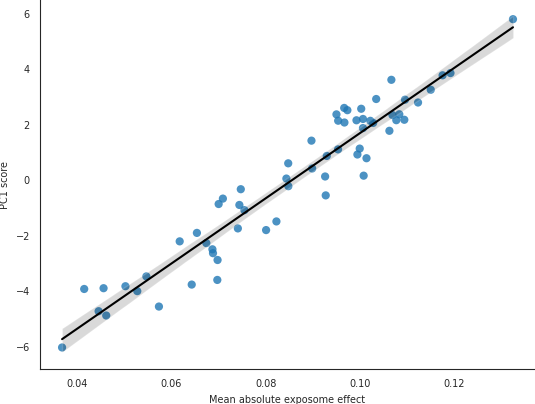

In [17]:
# PC1 vs mean absolute exposome effect across all tracts
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# Same tract x 21-metric matrix used for the observed PCA
effect_mat_observed=np.asarray(pca_observed["matrix"],dtype=float)

# Equal-weighted mean absolute exposome effect for each tract
mean_abs_effect_observed=np.nanmean(np.abs(effect_mat_observed),axis=1)

pc1_mean_df=pd.DataFrame({
    "bundle":bundles_boot,
    "PC1":pc1_observed,
    "mean_abs_effect":mean_abs_effect_observed
}).dropna()

r_pc1_mean,p_pc1_mean=pearsonr(
    pc1_mean_df["PC1"],
    pc1_mean_df["mean_abs_effect"]
)

print(f"N tracts = {len(pc1_mean_df)}")
print(f"PC1 vs mean absolute exposome effect: r = {r_pc1_mean:.3f}, p = {p_pc1_mean:.3g}")
print(f"|r| = {abs(r_pc1_mean):.3f}")

sns.regplot(
    data=pc1_mean_df,
    x="mean_abs_effect",
    y="PC1",
    scatter_kws={"s":35,"alpha":.8,"edgecolor":"none"},
    line_kws={"color":"black"}
)

plt.xlabel("Mean absolute exposome effect")
plt.ylabel("PC1 score")
sns.despine()
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# Extract mean tract length from the RAW harmonized participant-level data.
# `mean_length_mm` is the primary quantity requested by the reviewer. It is also
# now retained as one of the macrostructural metrics entering corrected PC1.
# -----------------------------------------------------------------------------
def find_raw_bundle_metric_columns(df, metric):
    bundle_cols = [c for c in df.columns if c.startswith("bundle_")]

    # Prefer the median participant-level summary, consistent with the Figure 2
    # choice to retain `_median` rather than `_mean` tract-profile summaries.
    preferred = [c for c in bundle_cols if c.endswith(f"_{metric}_median")]
    if preferred:
        return sorted(preferred)

    exact = [c for c in bundle_cols if c.endswith(f"_{metric}")]
    if exact:
        return sorted(exact)

    return sorted(c for c in bundle_cols if f"_{metric}" in c)


def raw_metric_matrix(df_raw, metric, target_bundles):
    cols = find_raw_bundle_metric_columns(df_raw, metric)
    if not cols:
        return None, []

    bundle_to_col = {}
    for c in cols:
        base = c[:-len("_median")] if c.endswith("_median") else c
        b, _ = parse_feature_name(base)
        bundle_to_col.setdefault(b, c)

    available_bundles = [b for b in target_bundles if b in bundle_to_col]
    if not available_bundles:
        return None, []

    arr = np.full((len(df_raw), len(target_bundles)), np.nan, dtype=float)
    sub = df_raw.reset_index(drop=True)

    for j, b in enumerate(target_bundles):
        c = bundle_to_col.get(b)
        if c is not None:
            arr[:, j] = pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)

    return arr, available_bundles


LENGTH_CANDIDATES = ["mean_length_mm"]
length_arrays = {}

for metric in LENGTH_CANDIDATES:
    arrA, bundlesA = raw_metric_matrix(dfA_raw, metric, bundles_boot)
    arrB, bundlesB = raw_metric_matrix(dfB_raw, metric, bundles_boot)

    if arrA is not None and arrB is not None:
        length_arrays[metric] = {"A": arrA, "B": arrB}
        print(
            f"Found {metric}: split A bundles={len(bundlesA)}, "
            f"split B bundles={len(bundlesB)}"
        )
    else:
        print(f"Did not find usable raw columns for {metric}.")

if "mean_length_mm" not in length_arrays:
    raise RuntimeError(
        "Could not extract mean_length_mm for the tract-length sensitivity analysis. "
        "Inspect the raw macrostructural column names before continuing."
    )


In [ ]:
# -----------------------------------------------------------------------------
# Bundle-level statistics.
# -----------------------------------------------------------------------------
sa_map = (
    tracts_with_sa_clean[["new_qsirecon_tract_names", "SA_Range"]]
    .drop_duplicates()
    .set_index("new_qsirecon_tract_names")["SA_Range"]
    .to_dict()
)
sa_values = np.array([sa_map.get(b, np.nan) for b in bundles_boot], dtype=float)


def _z(v):
    v = np.asarray(v, dtype=float)
    return (v - np.nanmean(v)) / np.nanstd(v, ddof=0)


def partial_corr_controlling_one(x, y, z):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[valid], y[valid], z[valid]

    Z = np.column_stack([np.ones(len(z)), z])
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return pearsonr(rx, ry)[0]


def standardized_beta_sa(pc1, sa, length):
    pc1 = np.asarray(pc1, dtype=float)
    sa = np.asarray(sa, dtype=float)
    length = np.asarray(length, dtype=float)
    valid = np.isfinite(pc1) & np.isfinite(sa) & np.isfinite(length)

    y = _z(pc1[valid])
    x_sa = _z(sa[valid])
    x_len = _z(length[valid])
    X = np.column_stack([np.ones(len(y)), x_sa, x_len])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return beta[1]


def bundle_stats(pc1, length_values):
    valid_sa = np.isfinite(pc1) & np.isfinite(sa_values)
    r_pc1_sa = pearsonr(pc1[valid_sa], sa_values[valid_sa])[0]

    valid_len = valid_sa & np.isfinite(length_values)
    r_sa_length = pearsonr(sa_values[valid_len], length_values[valid_len])[0]
    r_pc1_length = pearsonr(pc1[valid_len], length_values[valid_len])[0]
    partial_r = partial_corr_controlling_one(pc1[valid_len], sa_values[valid_len], length_values[valid_len])
    beta_sa = standardized_beta_sa(pc1[valid_len], sa_values[valid_len], length_values[valid_len])

    return {
        "n_bundles": int(valid_len.sum()),
        "r_pc1_sa": r_pc1_sa,
        "r_sa_length": r_sa_length,
        "r_pc1_length": r_pc1_length,
        "partial_r_pc1_sa_given_length": partial_r,
        "std_beta_sa_given_length": beta_sa,
    }


def mean_length_from_indices(length_pair, idxA=None, idxB=None):
    """Average participant-level tract length within each split, then across splits.

    In bootstrap replicates the mean is recomputed from the resampled participants,
    so the length covariate also carries participant-sampling uncertainty.
    """
    A = length_pair["A"] if idxA is None else length_pair["A"][idxA]
    B = length_pair["B"] if idxB is None else length_pair["B"][idxB]

    meanA = np.nanmean(A, axis=0)
    meanB = np.nanmean(B, axis=0)
    return np.nanmean(np.vstack([meanA, meanB]), axis=0)


observed_stats = {}
observed_bundle_tables = {}

for length_metric, length_pair in length_arrays.items():
    tract_length_observed = mean_length_from_indices(length_pair)
    stats = bundle_stats(pc1_observed, tract_length_observed)
    observed_stats[length_metric] = stats

    table = pd.DataFrame({
        "bundle": bundles_boot,
        "PC1": pc1_observed,
        "SA_Range": sa_values,
        length_metric: tract_length_observed,
    }).dropna()
    observed_bundle_tables[length_metric] = table
    table.to_csv(REVIEW_DIR / f"observed_bundle_table_{length_metric}.csv", index=False)

    print(f"\nObserved results using {length_metric}")
    for key, value in stats.items():
        print(f"  {key}: {value}")

# -----------------------------------------------------------------------------
# mean absolute exposome effect across metrics.
# -----------------------------------------------------------------------------
effect_mat_observed = np.asarray(pca_observed["matrix"], dtype=float)
mean_abs_effect_observed = np.nanmean(np.abs(effect_mat_observed), axis=1)

valid_mean_abs_sa = np.isfinite(mean_abs_effect_observed) & np.isfinite(sa_values)
observed_r_mean_abs_sa = pearsonr(
    mean_abs_effect_observed[valid_mean_abs_sa],
    sa_values[valid_mean_abs_sa],
)[0]

observed_mean_abs_stats = {}
for length_metric, length_pair in length_arrays.items():
    tract_length_observed = mean_length_from_indices(length_pair)
    stats = bundle_stats(mean_abs_effect_observed, tract_length_observed)
    observed_mean_abs_stats[length_metric] = stats

    table = pd.DataFrame({
        "bundle": bundles_boot,
        "mean_abs_effect_21metrics": mean_abs_effect_observed,
        "SA_Range": sa_values,
        length_metric: tract_length_observed,
    }).dropna()
    table.to_csv(
        REVIEW_DIR / f"observed_mean_abs_summary_{length_metric}.csv",
        index=False,
    )

print("\nObserved reviewer benchmark: mean absolute effect across 21 metrics")
print(f"  n_bundles: {int(valid_mean_abs_sa.sum())}")
print(f"  r_mean_abs_sa: {observed_r_mean_abs_sa}")
for length_metric, stats in observed_mean_abs_stats.items():
    print(f"  using {length_metric}:")
    print("partial_r_mean_abs_sa_given_length:", stats["partial_r_pc1_sa_given_length"])
    print("std_beta_sa_given_length:", stats["std_beta_sa_given_length"])

### bootstrap of mean absolute exposome effect size

This revision carries the **mean absolute exposome effect across all 21 WM metrics** through the same participant-level bootstrap used for PC1. For each bootstrap replicate, participants are resampled separately within discovery and replication splits, all tract-by-metric General Exposome effects are re-estimated, the split-averaged mean-absolute tract summary is recomputed, raw mean tract length is recomputed from the resampled participants, and both unadjusted and tract-length-adjusted S–A associations are evaluated.


In [ ]:
# -----------------------------------------------------------------------------
# Participant bootstrap: this occurs BEFORE the mass-univariate effects.
# Each replicate resamples participants WITH replacement separately in A and B,
# preserving every resampled participant's full tract-feature vector. After that
# resampling, all tract x metric partial-r effects are recomputed from scratch.
# We then derive BOTH:
#   (1) the PCA/PC1 summary, and
#   (2) mean-absolute-effect summary across all 21 metrics.
# Raw mean tract length is also recomputed from the same resampled participants.
# -----------------------------------------------------------------------------
rng = np.random.default_rng(BOOT_SEED)
bootstrap_rows = []

nA = len(prepA["Y"])
nB = len(prepB["Y"])

for b in range(N_BOOT):
    idxA = rng.integers(0, nA, size=nA)
    idxB = rng.integers(0, nB, size=nB)

    # Re-estimate every tract x metric General Exposome effect after participant resampling.
    rA_b = partial_r_fast_exact(prepA, idxA)
    rB_b = partial_r_fast_exact(prepB, idxB)

    # Reconstruct averaged tract x metric effect matrix and refit PCA.
    pca_b = pca_from_split_r(rA_b, rB_b)
    pc1_b, _, loading_alignment_b = align_pc1_to_reference(pca_b)

    # Reviewer's transparent benchmark: equal weighting across the same 21 effects.
    mean_abs_b = np.nanmean(np.abs(pca_b["matrix"]), axis=1)

    row = {
        "bootstrap": b + 1,
        "pc1_loading_alignment_abs_r": loading_alignment_b,
        "pc1_explained_var": pca_b["explained"][0],
    }

    # Unadjusted S-A associations.
    valid_pc1_sa = np.isfinite(pc1_b) & np.isfinite(sa_values)
    row["r_pc1_sa"] = pearsonr(
        pc1_b[valid_pc1_sa], sa_values[valid_pc1_sa]
    )[0]

    valid_mean_abs_sa = np.isfinite(mean_abs_b) & np.isfinite(sa_values)
    row["r_mean_abs_sa"] = pearsonr(
        mean_abs_b[valid_mean_abs_sa], sa_values[valid_mean_abs_sa]
    )[0]

    for length_metric, length_pair in length_arrays.items():
        # Recompute raw tract length from the resampled participants.
        tract_length_b = mean_length_from_indices(length_pair, idxA, idxB)
        prefix = length_metric

        # Original PC1 sensitivity analysis.
        pc1_stats_b = bundle_stats(pc1_b, tract_length_b)
        row[f"{prefix}__r_sa_length"] = pc1_stats_b["r_sa_length"]
        row[f"{prefix}__r_pc1_length"] = pc1_stats_b["r_pc1_length"]
        row[f"{prefix}__partial_r_pc1_sa_given_length"] = pc1_stats_b[
            "partial_r_pc1_sa_given_length"
        ]
        row[f"{prefix}__std_beta_sa_given_length"] = pc1_stats_b[
            "std_beta_sa_given_length"
        ]

        # Reviewer's simple mean-absolute-effect summary, adjusted for raw tract length.
        mean_abs_stats_b = bundle_stats(mean_abs_b, tract_length_b)
        row[f"{prefix}__r_mean_abs_length"] = mean_abs_stats_b["r_pc1_length"]
        row[f"{prefix}__partial_r_mean_abs_sa_given_length"] = mean_abs_stats_b[
            "partial_r_pc1_sa_given_length"
        ]
        row[f"{prefix}__std_beta_mean_abs_sa_given_length"] = mean_abs_stats_b[
            "std_beta_sa_given_length"
        ]

    bootstrap_rows.append(row)

    if (b + 1) % PROGRESS_EVERY == 0 or (b + 1) == N_BOOT:
        print(f"Completed {b + 1}/{N_BOOT} bootstrap replicates")

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_path = REVIEW_DIR / f"participant_bootstrap_B{N_BOOT}_seed{BOOT_SEED}.csv"
bootstrap_df.to_csv(bootstrap_path, index=False)
print("Saved bootstrap replicates to:", bootstrap_path)


In [ ]:
# -----------------------------------------------------------------------------
# Participant-bootstrap confidence intervals and approximate two-sided p-values.
#
# Primary uncertainty statement: percentile 95% bootstrap CI.
# Primary bootstrap p-value: center the bootstrap deviations around the observed
# estimate to approximate the null distribution, then compare |theta_hat| with
# |theta* - theta_hat|. A sign-tail probability is also saved as a diagnostic.
# Neither is a tract-permutation/spatial-null p-value.
# -----------------------------------------------------------------------------
def bootstrap_inference(observed, bootstrap_values, alpha=0.05):
    boot = np.asarray(bootstrap_values, dtype=float)
    boot = boot[np.isfinite(boot)]

    ci_low, ci_high = np.quantile(boot, [alpha / 2, 1 - alpha / 2])

    # Null-centered bootstrap test for H0: theta = 0.
    centered = boot - observed
    p_centered = (
        np.sum(np.abs(centered) >= abs(observed)) + 1
    ) / (len(centered) + 1)

    # Diagnostic: proportion of bootstrap estimates on either side of zero.
    p_lower = (np.sum(boot <= 0) + 1) / (len(boot) + 1)
    p_upper = (np.sum(boot >= 0) + 1) / (len(boot) + 1)
    p_sign_tail = min(1.0, 2 * min(p_lower, p_upper))

    return {
        "observed": observed,
        "ci_2.5%": ci_low,
        "ci_97.5%": ci_high,
        "p_boot_centered": p_centered,
        "p_boot_sign_tail_diagnostic": p_sign_tail,
        "bootstrap_se": np.std(boot, ddof=1),
        "n_boot": len(boot),
    }


summary_rows = []

# -----------------------------------------------------------------------------
# Original PC1 S-A result.
# -----------------------------------------------------------------------------
obs_r_sa = next(iter(observed_stats.values()))["r_pc1_sa"]
inf = bootstrap_inference(obs_r_sa, bootstrap_df["r_pc1_sa"])
summary_rows.append({
    "analysis": "PC1 vs SA_Range",
    "length_metric": "none",
    **inf,
})

# -----------------------------------------------------------------------------
# Reviewer's transparent equal-weighted benchmark.
# -----------------------------------------------------------------------------
inf = bootstrap_inference(
    observed_r_mean_abs_sa,
    bootstrap_df["r_mean_abs_sa"],
)
summary_rows.append({
    "analysis": "Mean absolute effect across 21 metrics vs SA_Range",
    "length_metric": "none",
    **inf,
})

for length_metric, obs in observed_stats.items():
    stat_map = {
        "SA_Range vs mean tract length": (
            obs["r_sa_length"],
            f"{length_metric}__r_sa_length",
        ),
        "PC1 vs mean tract length": (
            obs["r_pc1_length"],
            f"{length_metric}__r_pc1_length",
        ),
        "PC1 vs SA_Range | mean tract length (partial r)": (
            obs["partial_r_pc1_sa_given_length"],
            f"{length_metric}__partial_r_pc1_sa_given_length",
        ),
        "PC1 ~ SA_Range + mean tract length (standardized beta SA)": (
            obs["std_beta_sa_given_length"],
            f"{length_metric}__std_beta_sa_given_length",
        ),
    }

    for label, (observed_value, boot_col) in stat_map.items():
        inf = bootstrap_inference(observed_value, bootstrap_df[boot_col])
        summary_rows.append({
            "analysis": label,
            "length_metric": length_metric,
            **inf,
        })

    # Length-adjusted inference for the simple summary.
    mean_obs = observed_mean_abs_stats[length_metric]
    mean_stat_map = {
        "Mean absolute effect vs mean tract length": (
            mean_obs["r_pc1_length"],
            f"{length_metric}__r_mean_abs_length",
        ),
        "Mean absolute effect vs SA_Range | mean tract length (partial r)": (
            mean_obs["partial_r_pc1_sa_given_length"],
            f"{length_metric}__partial_r_mean_abs_sa_given_length",
        ),
        "Mean absolute effect ~ SA_Range + mean tract length (standardized beta SA)": (
            mean_obs["std_beta_sa_given_length"],
            f"{length_metric}__std_beta_mean_abs_sa_given_length",
        ),
    }

    for label, (observed_value, boot_col) in mean_stat_map.items():
        inf = bootstrap_inference(observed_value, bootstrap_df[boot_col])
        summary_rows.append({
            "analysis": label,
            "length_metric": length_metric,
            **inf,
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = REVIEW_DIR / f"participant_bootstrap_summary_B{N_BOOT}_seed{BOOT_SEED}.csv"
summary_df.to_csv(summary_path, index=False)

print(summary_df.to_string(index=False))
print("\nSaved summary to:", summary_path)
print(
    "\nPC1 bootstrap loading-alignment diagnostic (absolute r):",
    bootstrap_df["pc1_loading_alignment_abs_r"].describe().to_dict(),
)

print("\nPrimary reviewer benchmark rows:")
print(
    summary_df[
        summary_df["analysis"].str.contains("Mean absolute effect", regex=False)
    ].to_string(index=False)
)


In [ ]:
primary_mean_rows = summary_df[summary_df["analysis"].isin([
    "Mean absolute effect across 21 metrics vs SA_Range",
    "Mean absolute effect vs SA_Range | mean tract length (partial r)",
    "Mean absolute effect ~ SA_Range + mean tract length (standardized beta SA)"])].copy()

primary_mean_path = REVIEW_DIR / ( f"mean_abs_primary_bootstrap_summary_B{N_BOOT}_seed{BOOT_SEED}.csv")
primary_mean_rows.to_csv(primary_mean_path, index=False)

print("\nPRIMARY MEAN-ABSOLUTE S-A RESULTS")
print(primary_mean_rows.to_string(index=False))
print("\nSaved manuscript-ready mean-summary results to:", primary_mean_path)